# Workflow for OHLC & gap trades

This notebook demonstrates how to use the helper modules in the repository.
You can change your directory paths in `config.py`, which all code refers to.


In [ ]:
# make sure the root of the project is on sys.path.  When VS Code
# opens the `notebooks` folder the current working directory may be the
# notebook directory rather than the project root.  Look for `config.py` and
# fall back to the parent directory if necessary.
import sys
from pathlib import Path

root = Path.cwd()
if not (root / "config.py").exists():
    root = root.parent
sys.path.insert(0, str(root))

# basic imports from the helper modules (now packaged under scripts)
from config import ROOT_DIR, ensure_directories
from scripts.daily_processing import merge_unfiltered, merge_processed
from scripts.gap_detection import detect_gaps
from scripts.intraday_slicer import slice_intraday
from scripts.significance import run_analysis
from scripts.split_significant import split_file
from scripts.earnings_processing import process_earnings
from scripts.earnings_gap_matcher import match_earnings_to_gaps
from scripts.plot_quartile_car import make_quartile_charts

# create any folders we will write to
ensure_directories()

print(f"project root is {ROOT_DIR}")

project root is C:\Users\j\python\Shocks_analysis_project


## Step 1 – combine raw daily files

The first function concatenates every text file in `data/daily_data` and
writes the unfiltered master CSV.  If the file already exists it will be
overwritten.

In [8]:
unfiltered_df = merge_unfiltered()
unfiltered_df.head()

Found 7117 daily files to merge


Merging tickers: 100%|██████████| 7117/7117 [00:38<00:00, 185.14it/s]


saved unfiltered file to C:\Users\j\python\Shocks_analysis_project\main_dataframe\daily_ohlc_unfiltered.csv with 11849649 rows


,Date,Open,High,Low,Close,Volume,Ticker
0,2025-04-07,0.1800,0.1800,0.1800,0.1800,112.0,AACBR
1,2025-04-10,0.1800,0.5746,0.1700,0.1800,795449.0,AACBR
2,2025-04-22,0.2000,0.2000,0.1790,0.1801,75318.0,AACBR
3,2025-04-24,0.1928,0.2063,0.1928,0.2063,205.0,AACBR
4,2025-04-25,0.1866,0.2200,0.1800,0.2000,278070.0,AACBR


## Step 2 – apply price & liquidity filters

In [9]:
processed_df = merge_processed()
processed_df.head()

Searching in: C:\Users\j\python\Shocks_analysis_project\data\daily_data
Found 7117 files matching the pattern.
saved filtered data to C:\Users\j\python\Shocks_analysis_project\main_dataframe\daily_ohlc_processed.csv (15306335 rows)


,Date,Open,High,Low,Close,Volume,Ticker,usd_volume,mean_usd_vol
0,2025-04-10,0.1800,0.5746,0.17000,0.18000,795449.0,AACBR,143180.82000,71600.490000
1,2025-04-25,0.1866,0.2200,0.18000,0.20000,278070.0,AACBR,55614.00000,42484.408660
2,2025-05-22,0.2000,0.2400,0.20000,0.24000,401966.0,AACBR,96471.84000,16587.166321
3,2025-09-19,0.2176,0.2399,0.21535,0.21931,294558.0,AACBR,64599.51498,6030.066325
4,2025-10-08,0.2260,0.2700,0.22600,0.26990,274049.0,AACBR,73965.82510,5612.072041


## Step 3 – detect overnight gaps and save results

In [10]:
gap_df = detect_gaps()
gap_df[['Ticker','Date','Is_Gap_Up','Is_Gap_Down']].head()

wrote 102774 gap ups and 77419 gap downs


,Ticker,Date,Is_Gap_Up,Is_Gap_Down
1215945,A,2015-01-02,False,False
1215946,A,2015-01-05,False,False
1215947,A,2015-01-06,False,False
1215948,A,2015-01-07,False,False
1215949,A,2015-01-08,False,False


## Step 4 – slice intraday data for each gap event

Reads the 1‑minute files and writes one CSV per gap day. Warning: takes a long time


In [3]:
slice_intraday()       

tickers: 100%|██████████| 6061/6061 [2:13:15<00:00,  1.32s/it]  


## Step 5 – flag significant gaps based on early volume

In [5]:
run_analysis()

 Found 178845 potential gap files.


Analyzing gaps: 100%|██████████| 178845/178845 [14:48<00:00, 201.32it/s]



Saved 19661 significant gaps to C:\Users\j\python\Shocks_analysis_project\main_dataframe\SIGNIFICANT_GAPS_final.csv


## Step 6 – optional: split the significance file into strategy buckets

In [6]:
split_file()

Loaded 19661 rows. Splitting into 3 groups
 saved 13092 rows to C:\Users\j\python\Shocks_analysis_project\main_dataframe\SIG_SPLITS\Sig30_P1.csv
 saved 16604 rows to C:\Users\j\python\Shocks_analysis_project\main_dataframe\SIG_SPLITS\Sig30_P5.csv
 saved 17942 rows to C:\Users\j\python\Shocks_analysis_project\main_dataframe\SIG_SPLITS\Sig30_P30.csv


## Step 7 – visualise a ticker

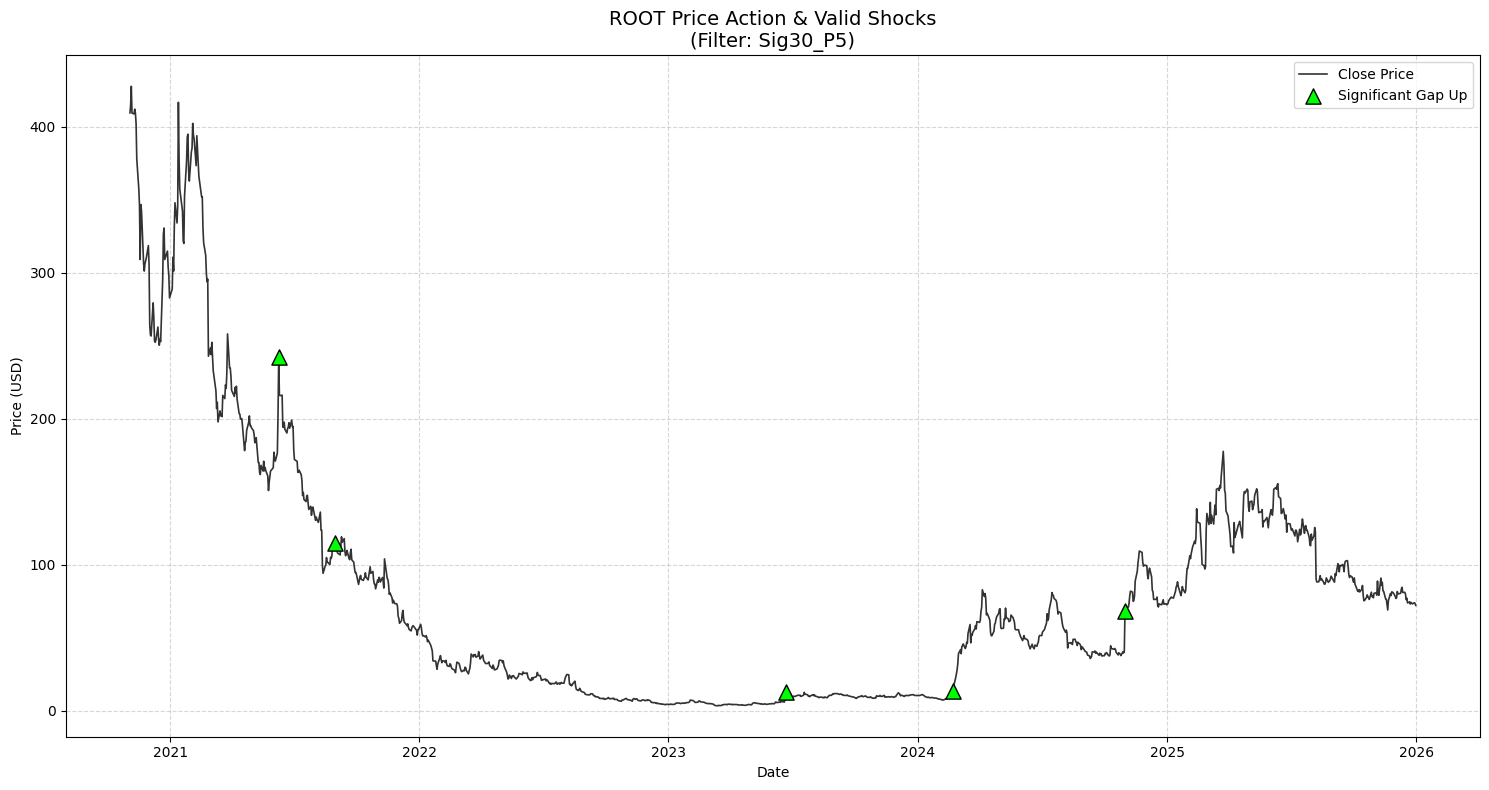

In [7]:
plot_ticker("ROOT", signal_col="Sig30_P5")

## Step 8 – process earnings and match to gaps

Computes SUE / SUR with winsorization, then matches earnings events to gap trades by date
(checks if earnings occurred on the gap day or the day before, to account for after-hours announcements).

In [2]:
earn = process_earnings()

loading C:\Users\j\python\Shocks_analysis_project\main_dataframe\earnings_master.csv
54,343 rows | 2,302 tickers
computing rolling standard deviations...
winsorizing...

DESCRIPTIVE STATISTICS FOR EARNINGS SURPRISE & SUE
                            Variable     N   NaN      Mean   Median        Std           Min        P1       P10      P90         Max
              EPS Surprise (%) – raw 53560   783 -0.027879 0.055556   8.097522  -1331.000000 -7.000000 -0.636364 0.800000  402.000000
          Revenue Surprise (%) – raw 45009  9334  0.269515 0.012142  15.358073     -8.692308 -0.823529 -0.104115 0.142508 2320.951220
       EPS Surprise (%) – winsorized 53560   783  0.053343 0.055556   1.820143    -12.676429 -7.000000 -0.636364 0.800000   11.000000
   Revenue Surprise (%) – winsorized 45009  9334  0.044302 0.012142   0.391495     -0.931729 -0.823529 -0.104115 0.142508    3.834759
                     SUE (EPS) – raw 44778  9565  0.380414 0.231560   4.699900   -444.426711 -5.479207 -1.134

## Step 9 – Quartile Assignment & Strategy Selection

Assign rolling quartile ranks to earnings metrics (EPS/Revenue surprise, SUE, SUR) based on prior occurrences in each significance window (1m, 5m, 30m). Use quartile rankings to define three portfolio strategies: baseline (all gaps), long-biased (top quartile positive surprises), and short-biased (bottom quartile negative surprises).

In [2]:
import importlib
import earnings_gap_matcher
importlib.reload(earnings_gap_matcher)
from earnings_gap_matcher import match_earnings_to_gaps

# call the matching routine (error previously due to missing Is_Gap_Up column)
merged, gap_up_earnings, gap_down_earnings = match_earnings_to_gaps()

# the function now also prints counts of gap-up/down matches broken down by
# Sig30_P1, Sig30_P5 and Sig30_P30; you can still inspect the returned dataframes
merged.head()

ModuleNotFoundError: No module named 'earnings_gap_matcher'